In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import mdata_utils

2025-10-27 14:06:19.958058: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-27 14:06:19.958419: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 14:06:20.023968: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-27 14:06:45.165069: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

# GEX

In [2]:
data_path = "/ix1/ylee/Yifan_Zhang/Code_data/external/_GSE223873 CD8 MC38-OVA"
mdata = mu.read(data_path + "/GSE223873_CD8_gex_tcr.h5mu")
mdata

MuData object with n_obs × n_vars = 2712 × 32285
  2 modalities
    gex:	2712 x 32285
      obs:	'sample_id', 'tissue'
    airr:	2712 x 0
      obsm:	'airr'

In [3]:
%cd $data_path

/ix1/ylee/Yifan_Zhang/Code_data/external/_GSE223873 CD8 MC38-OVA


In [4]:
mdata.obs['GSE'] = 'GSE223873'
mdata.obs['GSM'] = mdata['gex'].obs['sample_id']
mdata.obs['tissue'] = mdata['gex'].obs['tissue']


In [5]:
## data specific features
mdata.obs['condition'] = 'EAE'
mdata['gex'].obs['cell_type'] = 'CD8'

In [6]:
mdata = mdata_utils.pp_EAE(mdata, celltype_score = 0.4, cellstate_score = 0.4, topN_variable = None)


In [7]:
mdata['gex'].obs['cell_type']

AAACCTGAGAGAGCTC-1-LN1     CD8
AAACGGGCATCGTCGG-1-LN1     CD8
AAACGGGTCTATGTGG-1-LN1     CD8
AAAGATGAGCTAACTC-1-LN1     CD8
AAAGATGGTCAAACTC-1-LN1     CD8
                          ... 
TTGCGTCGTCCTGCTT-1-CNS1    CD8
TTGGCAATCTACCAGA-1-CNS1    CD8
TTGTAGGGTTACGACT-1-CNS1    CD8
TTTACTGTCTTCAACT-1-CNS1    CD8
TTTGCGCAGTTTCCTT-1-CNS1    CD8
Name: cell_type, Length: 2706, dtype: object

# TCR

In [8]:
# mdata = mdata_ori.copy()
mdata['airr'].obs['sample_id'] = mdata.obs['sample_id']

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only", within_group = 'sample_id')

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

df2_filtered = meta_airr.loc[:, ~meta_airr.columns.isin(mdata.obs.columns)]
mdata.obs = mdata.obs.join(df2_filtered)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
ir.tl.clonal_expansion(mdata)


In [9]:
mdata

MuData object with n_obs × n_vars = 2712 × 10073
  obs:	'GSE', 'GSM', 'tissue', 'condition', 'state', 'cell_type', 'sample_id', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	2706 x 10073
      obs:	'sample_id', 'tissue', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	2712 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [10]:
count = (mdata['airr'].obs['clone_id_size'] == 1).sum()
print(count)

2531


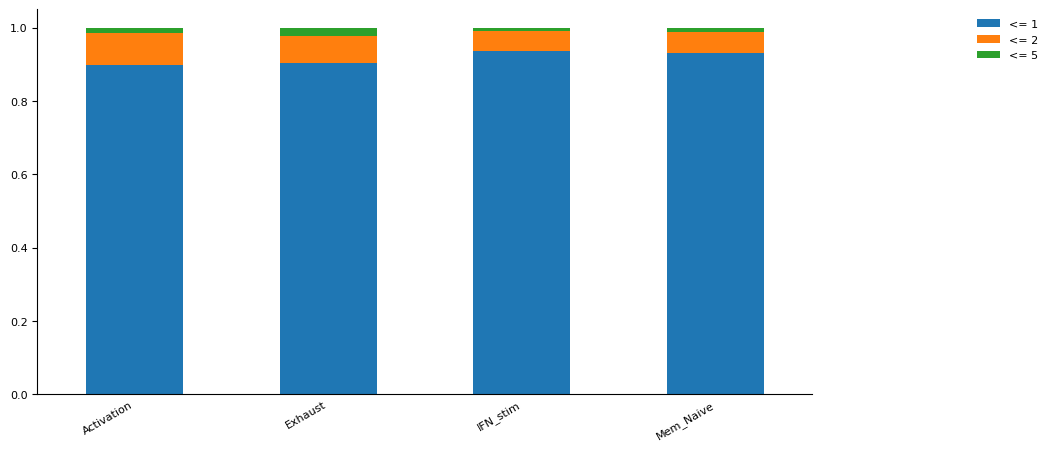

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="state",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

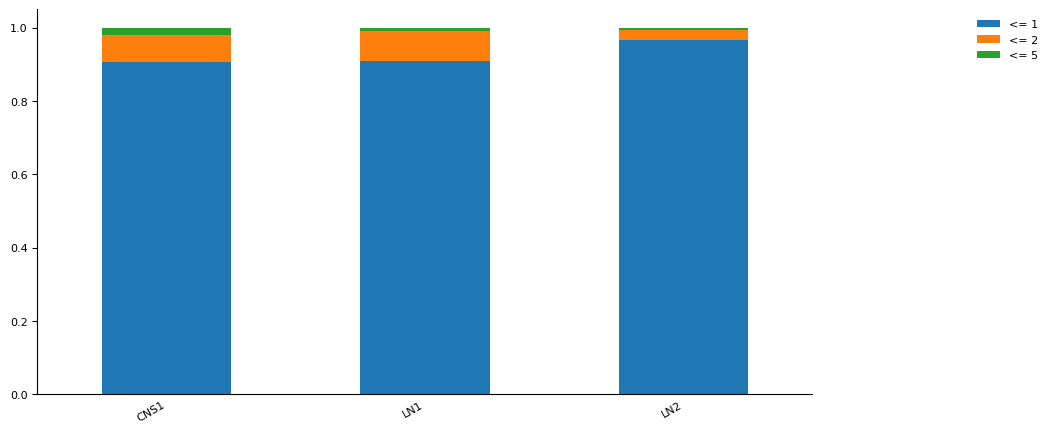

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'sample_id',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

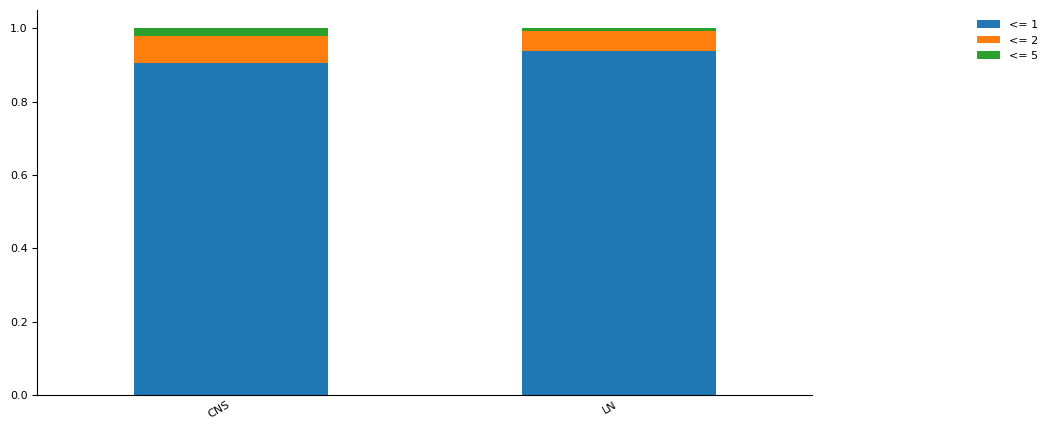

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'tissue',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

In [14]:
mdata.write('yz_processed_allGenes_annotateByRef.h5mu')
# mdata.write('yz_processed_allGenes_annotateByScore.h5mu')

In [15]:
aa

NameError: name 'aa' is not defined

In [ ]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)

In [ ]:
sc.pl.umap(mdata["gex"], color=['state', 'tissue', 'cell_type', 'sample_id'], ncols=2,)

In [ ]:
# markers_in = []
# for i in ['Ccr6', 'Il22', 'Il17', 'Il17a'] + genes:
#     if i in mdata["gex"].var_names:
#         markers_in.append(i) 
# mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)